# GCI - Final Assignment (due Jun 19th 11AM UTC)

# Project - Predictive_Retention_Strategy

This project stems from the need to understand a fundamental problem:



*   **the high financial and operational costs associated with employee turnover.**

Therefore, it proposes predicting which employees are most likely to resign, in order to manage these departures before they occur. At the business level, the problem stems from the following factors:

*  **High recruitment costs:** Hiring and retaining employees are extremely complex tasks that require capital and time. Companies spend between 15% and 20% of an employee's salary just on the recruitment process, which translates to an average cost of $7,645 per new hire.

*   **Impact on productivity and time:** Filling a vacant position takes an average of 52 days. Furthermore, employers can invest up to 40% of their working hours in tasks that do not generate direct revenue, such as recruitment. And an average company loses between 1% and 2.5% of its total revenue while a new employee adapts and reaches their optimal productivity level.

To address this problem, the document proposes a solution based on Data Science. It presents a scenario in which the Human Resources team collects extensive data on personnel—such as job satisfaction, work-life balance, education level, and performance rating—to develop a predictive model capable of identifying employees at risk of leaving the company.


# Main hypothesis of the project:

"Applying machine learning classification algorithms to historical data and employee well-being metrics will allow us to accurately predict which employees are at high risk of resigning, enabling Human Resources to implement proactive retention strategies and avoid the significant financial losses associated with staff turnover."

For this Data Science project to be executable, the hypothesis is broken down into the following technical components:

* **Target Variable:** The problem will be addressed as a binary classification model, where the output will be to determine which class the employee belongs to, for example, "0" (stays with the company) or "1" (resigns).

* **Predictor Variables (Features):** The model's predictions will be based on the characteristics and metrics collected by the HR team. These independent variables include level of involvement (JobInvolvement), education level (Education), job satisfaction (JobSatisfaction), performance rating (PerformanceRating), relationship satisfaction (RelationshipSatisfaction), and work-life balance (WorkLifeBalance).

* **Algorithms to be evaluated:** To find the best predictions, different predictive models will be tested and compared, such as Artificial Neural Networks, Logistic Regression, and decision tree-based classifiers, such as Random Forests.

* **Validation and Success Criteria:** The technical hypothesis assumes that turnover data will be unbalanced (i.e., the vast majority of employees stay, compared to a minority who resign). Therefore, the model will not be evaluated based on its overall accuracy, as this metric is misleading in these cases. The model will be considered successful if it optimizes metrics such as Recall and F1-Score.Maximizing Recall is crucial because it tells us how often the algorithm correctly identifies an employee who is truly about to resign (True Positives), minimizing False Negatives (at-risk employees that the model did not detect).

* **Expected Business Impact:** By validating this hypothesis and putting the model into production, the company will be able to identify potential departures early and significantly reduce its operating costs, avoiding the loss of the equivalent of 20% of annual salary or an average of $7,645 in recruitment costs for each employee replaced.

Note: The webpage "The True Cost of Hiring an Employee in 2024" is used in the project justification solely to substantiate the financial impact of the business problem; for example, it provides the statistics that the average cost of hiring a new employee ranges from $4,700 to $7,645.

Therefore, the webpage provides the economic context, while Kaggle provides the tabular data (CSV) for the algorithm.


[Source: https://toggl.com/blog/cost-of-hiring-an-employee](https://toggl.com/blog/cost-of-hiring-an-employee)

# Import Libraries and Datasets

The dataset comes from a public repository hosted on the Kaggle platform.

Specifically, the technical presentation indicates that the data corresponds to the "IBM HR Analytics Attrition Dataset," whose source link is: https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset

This dataset contains employee history and the variables necessary to train the predictive model, such as engagement level, education, and job satisfaction.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# You have to include the full link to the csv file containing your dataset
employee_df = pd.read_csv('/data/Human_Resources.csv')

In [4]:
employee_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
employee_df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
employee_df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
employee_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [9]:
employee_df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


# Visualize Dataset

In [10]:
# Let's replace the 'Attritition' and 'overtime' column with integers before performing any visualizations
employee_df['Attrition'] = employee_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
employee_df['OverTime'] = employee_df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)
employee_df['Over18'] = employee_df['Over18'].apply(lambda x: 1 if x == 'Y' else 0)

In [11]:
employee_df.head(4)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0


<Axes: >

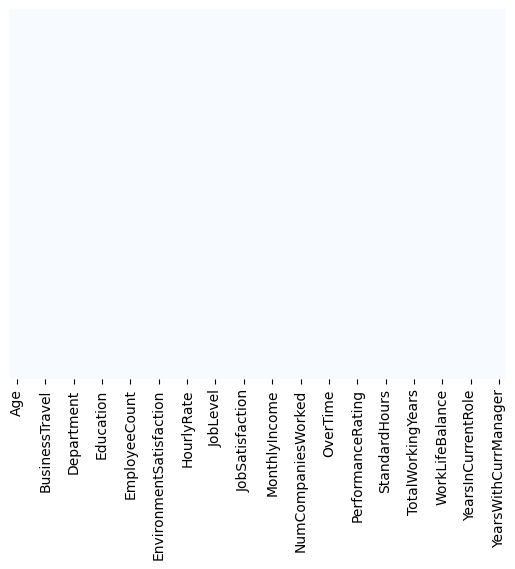

In [12]:
# Let's see if we have any missing data, luckily we don't!
sns.heatmap(employee_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Attrition'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'EmployeeCount'}>,
        <Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>],
       [<Axes: title={'center': 'JobLevel'}>,
        <Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>],
       [<Axes: title={'center': 'Over18'}>,
        <Axes: title={'center': 'OverTime'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>,
        <Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'Relations

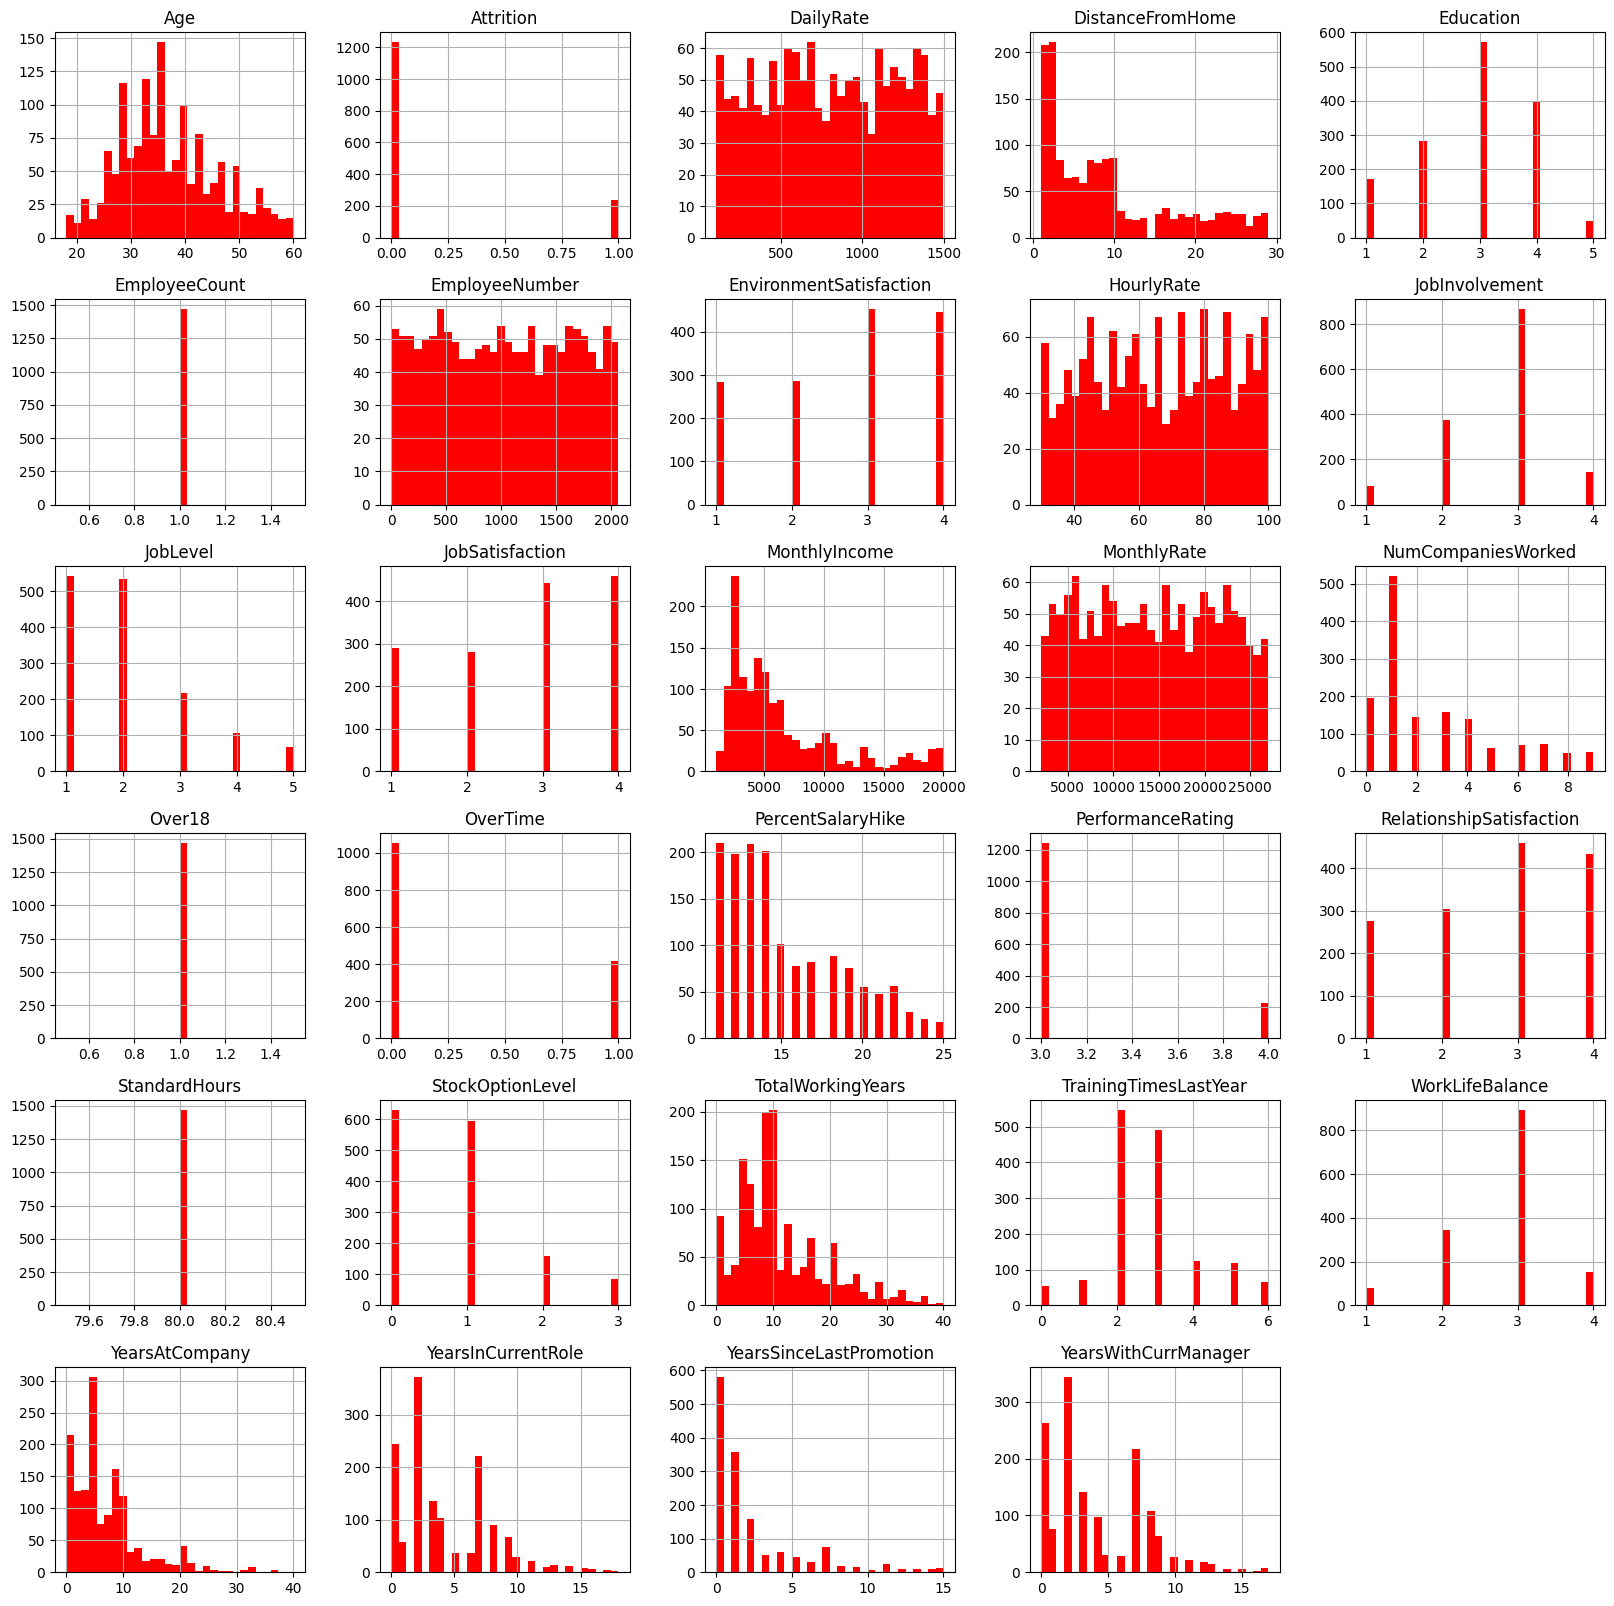

In [13]:
employee_df.hist(bins = 30, figsize = (20,20), color = 'r')
# Several features such as 'MonthlyIncome' and 'TotalWorkingYears' are tail heavy
# It makes sense to drop 'EmployeeCount' and 'Standardhours' since they do not change from one employee to the other

In [14]:
# It makes sense to drop 'EmployeeCount' , 'Standardhours' and 'Over18' since they do not change from one employee to the other
# Let's drop 'EmployeeNumber' as well
employee_df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1, inplace=True)

In [15]:
# Let's see how many employees left the company!
left_df = employee_df[employee_df['Attrition'] == 1]
stayed_df = employee_df[employee_df['Attrition'] == 0]

In [16]:
# Count the number of employees who stayed and left
# It seems that we are dealing with an imbalanced dataset

print("Total =", len(employee_df))

print("Number of employees who left the company =", len(left_df))
print("Percentage of employees who left the company =", 1.*len(left_df)/len(employee_df)*100.0, "%")

print("Number of employees who did not leave the company (stayed) =", len(stayed_df))
print("Percentage of employees who did not leave the company (stayed) =", 1.*len(stayed_df)/len(employee_df)*100.0, "%")

Total = 1470
Number of employees who left the company = 237
Percentage of employees who left the company = 16.122448979591837 %
Number of employees who did not leave the company (stayed) = 1233
Percentage of employees who did not leave the company (stayed) = 83.87755102040816 %


In [17]:
# Let's compare the mean and std of the employees who stayed and left
# 'age': mean age of the employees who stayed is higher compared to who left
# 'DailyRate': Rate of employees who stayed is higher
# 'DistanceFromHome': Employees who stayed live closer to home
# 'EnvironmentSatisfaction' & 'JobSatisfaction': Employees who stayed are generally more satisifed with their jobs
# 'StockOptionLevel': Employees who stayed tend to have higher stock option level

In [18]:
left_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,237.000000,237.0,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,...,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
mean,33.607595,1.0,750.362869,10.632911,2.839662,2.464135,65.573840,2.518987,1.637131,2.468354,...,3.156118,2.599156,0.527426,8.244726,2.624473,2.658228,5.130802,2.902954,1.945148,2.852321
std,9.689350,0.0,401.899519,8.452525,1.008244,1.169791,20.099958,0.773405,0.940594,1.118058,...,0.363735,1.125437,0.856361,7.169204,1.254784,0.816453,5.949984,3.174827,3.153077,3.143349
min,18.000000,1.0,103.000000,1.000000,1.000000,1.000000,31.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.0,408.000000,3.000000,2.000000,1.000000,50.000000,2.000000,1.000000,1.000000,...,3.000000,2.000000,0.000000,3.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,32.000000,1.0,699.000000,9.000000,3.000000,3.000000,66.000000,3.000000,1.000000,3.000000,...,3.000000,3.000000,0.000000,7.000000,2.000000,3.000000,3.000000,2.000000,1.000000,2.000000
75%,39.000000,1.0,1092.000000,17.000000,4.000000,4.000000,84.000000,3.000000,2.000000,3.000000,...,3.000000,4.000000,1.000000,10.000000,3.000000,3.000000,7.000000,4.000000,2.000000,5.000000
max,58.000000,1.0,1496.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,15.000000,15.000000,14.000000


In [19]:
stayed_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1233.000000,1233.0,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,...,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000
mean,37.561233,0.0,812.504461,8.915653,2.927007,2.771290,65.952149,2.770479,2.145985,2.778589,...,3.153285,2.733982,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
std,8.888360,0.0,403.208379,8.012633,1.027002,1.071132,20.380754,0.692050,1.117933,1.093277,...,0.360408,1.071603,0.841985,7.760719,1.293585,0.681907,6.096298,3.649402,3.234762,3.594116
min,18.000000,0.0,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.0,477.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.0,817.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,43.000000,0.0,1176.000000,13.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,16.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,0.0,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,38.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


In [20]:
employee_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


<Axes: >

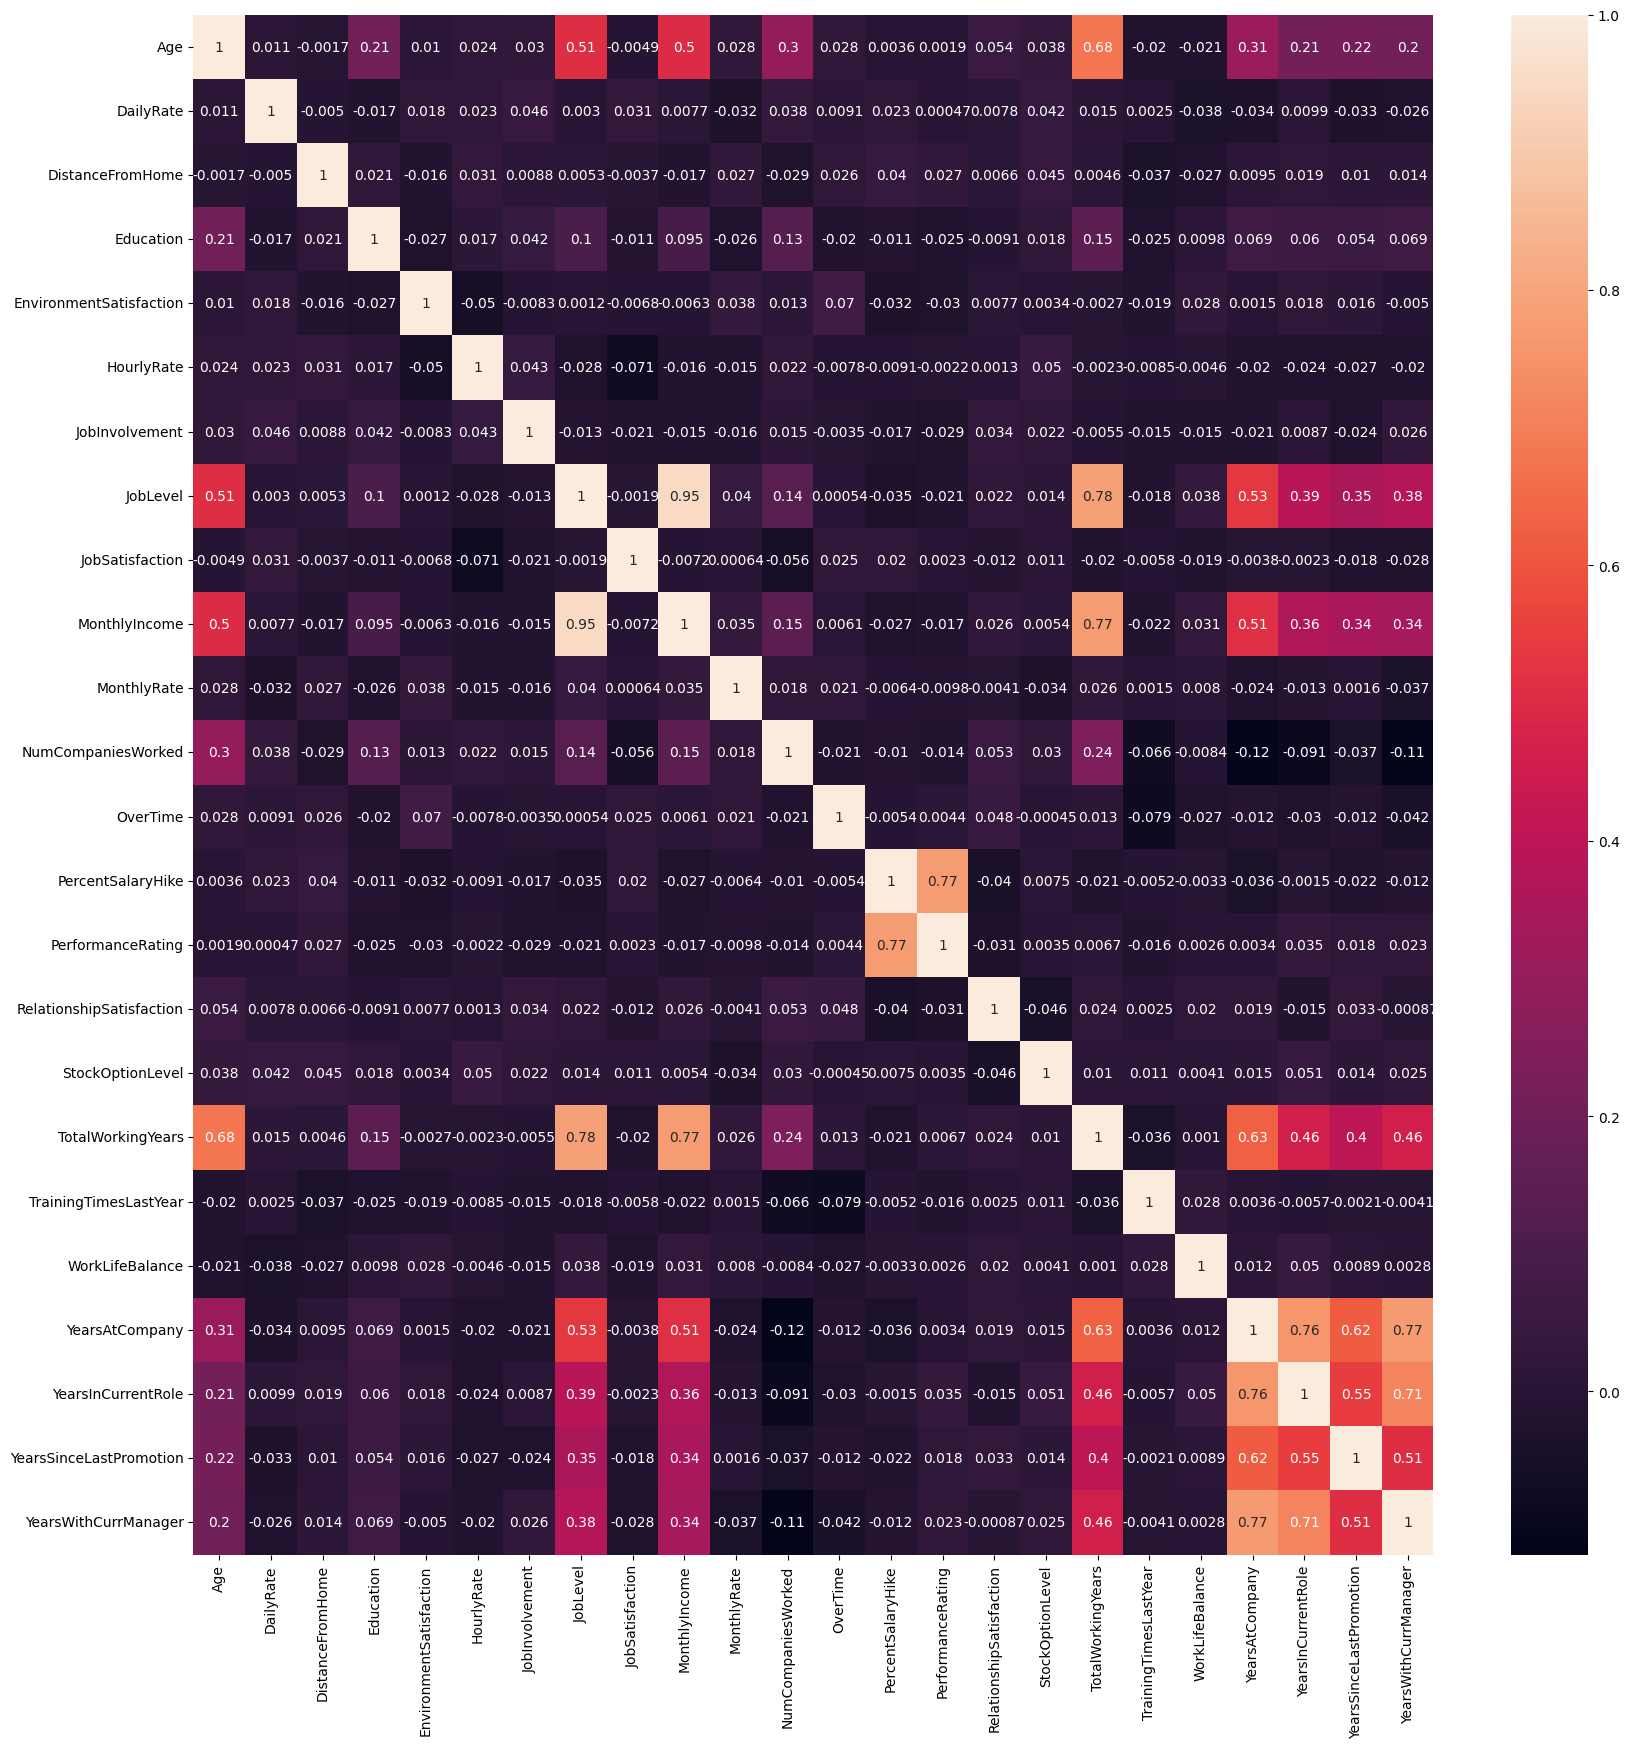

In [21]:
numeric_df = employee_df.select_dtypes(include=np.number).drop('Attrition', axis=1)
correlations = numeric_df.corr()
f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True)

In [22]:
# Job level is strongly correlated with total working hours
# Monthly income is strongly correlated with Job level
# Monthly income is strongly correlated with total working hours
# Age is stongly correlated with monthly income

<Axes: xlabel='Age', ylabel='count'>

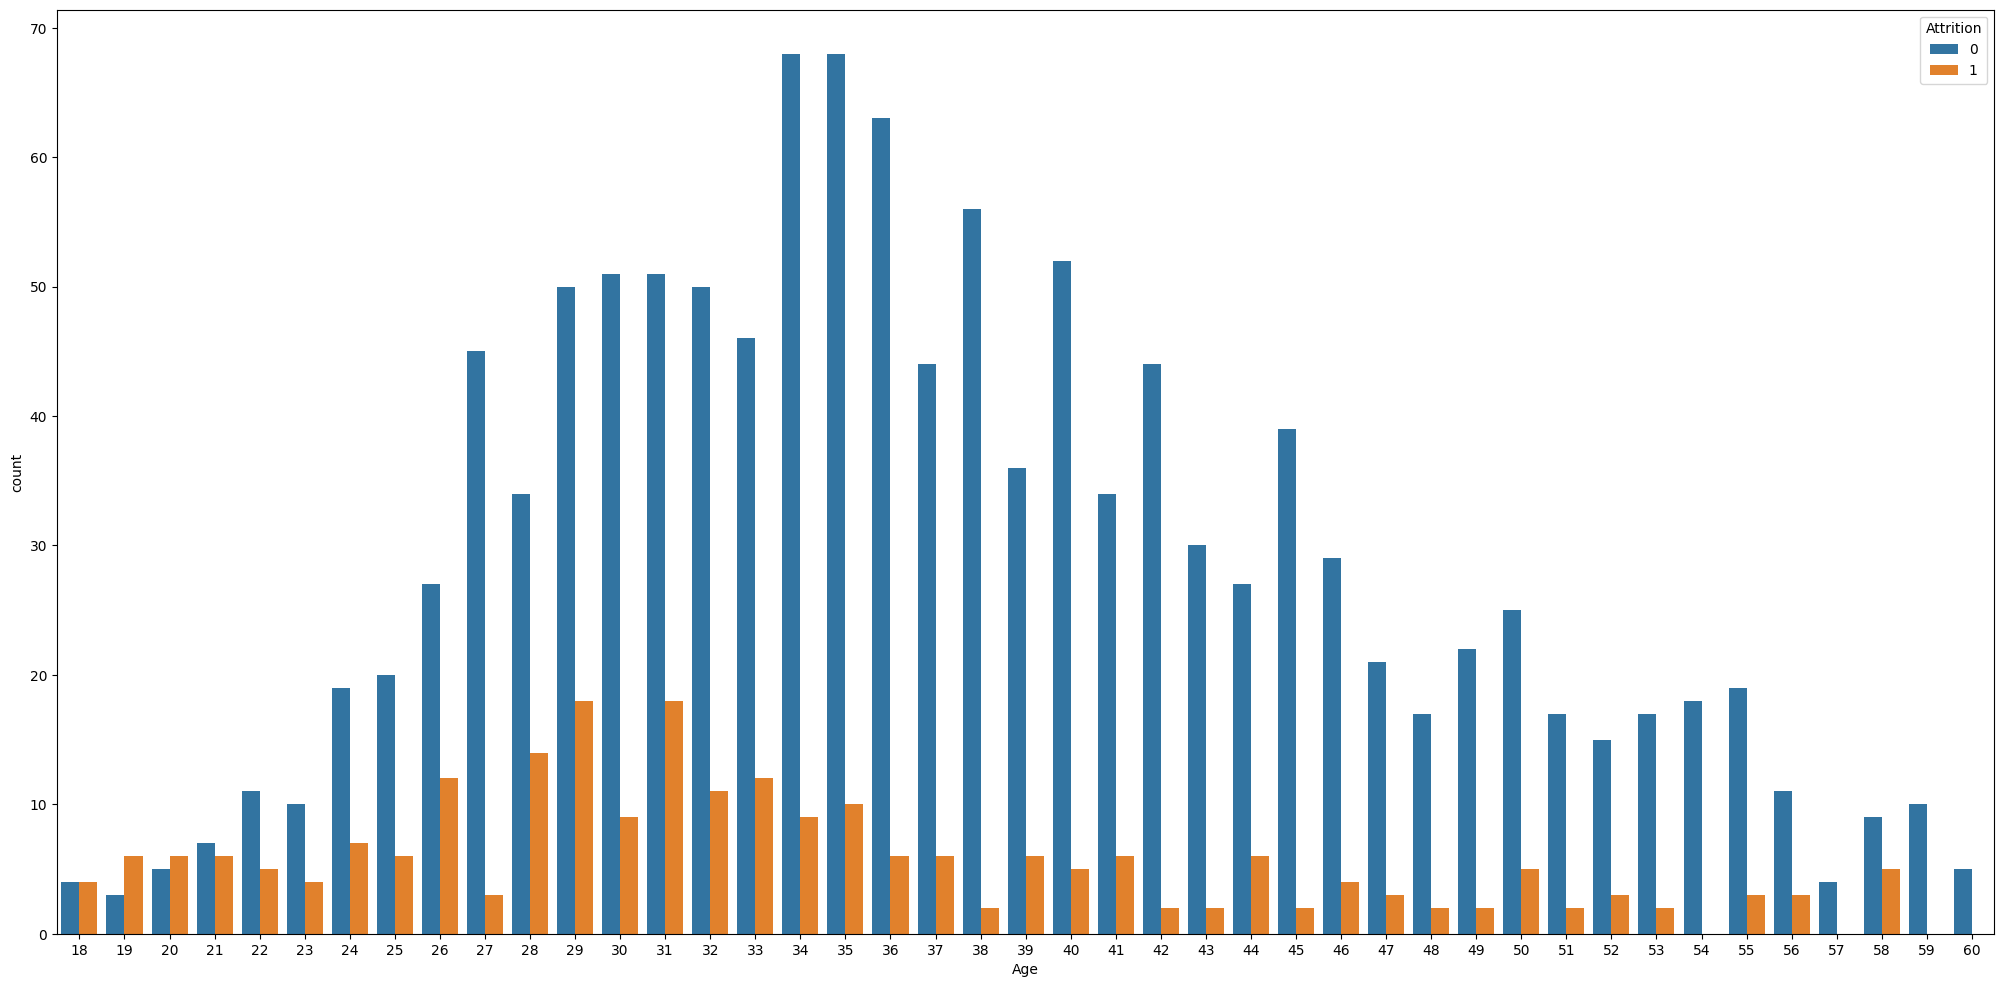

In [23]:
plt.figure(figsize=[25, 12])
sns.countplot(x = 'Age', hue = 'Attrition', data = employee_df)

<Axes: xlabel='JobLevel', ylabel='count'>

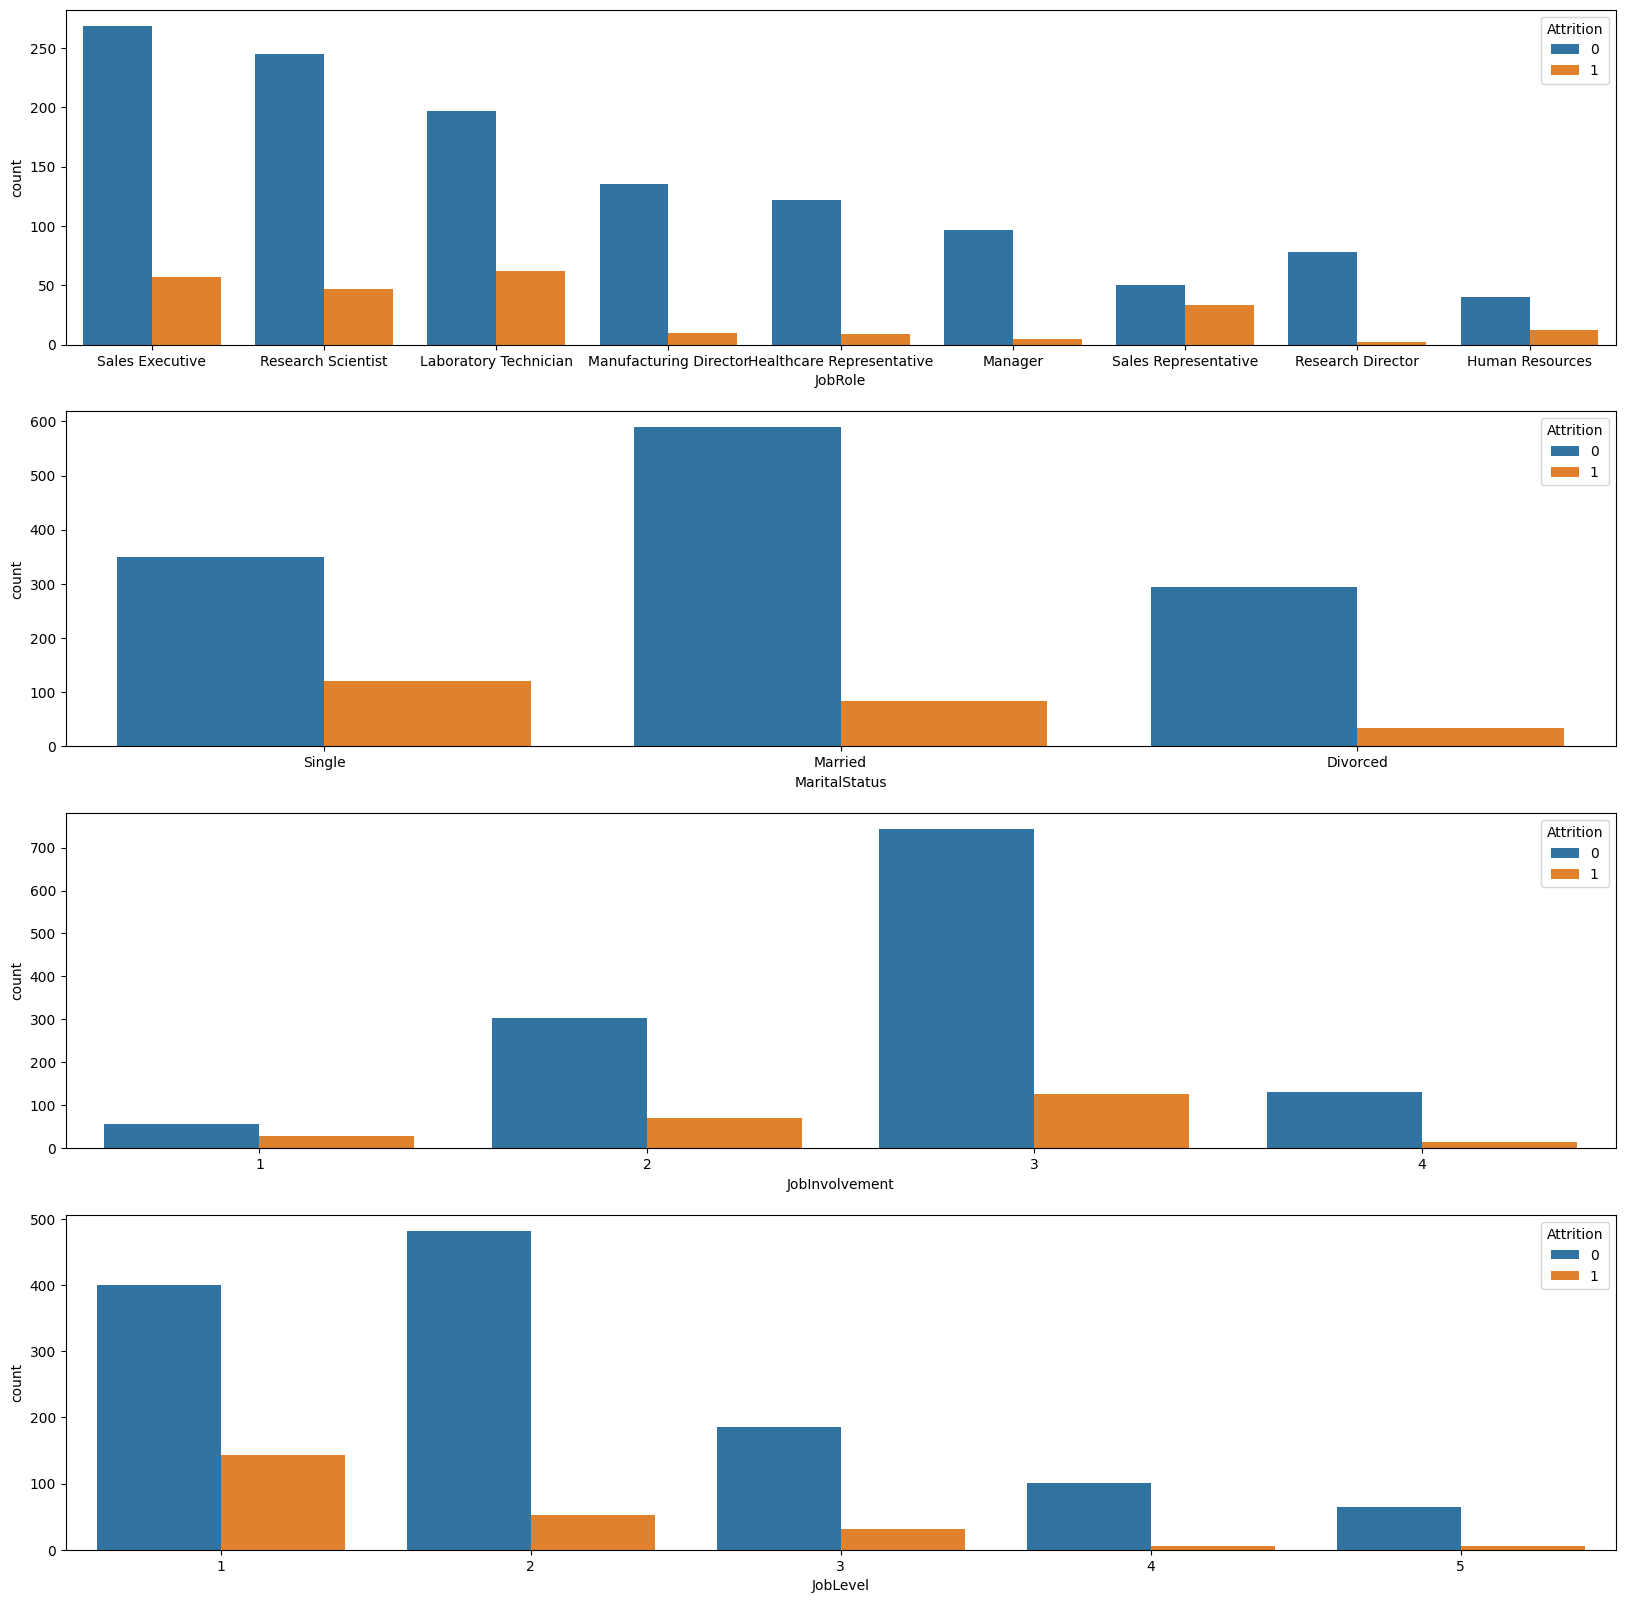

In [24]:
plt.figure(figsize=[20,20])
plt.subplot(411)
sns.countplot(x = 'JobRole', hue = 'Attrition', data = employee_df)
plt.subplot(412)
sns.countplot(x = 'MaritalStatus', hue = 'Attrition', data = employee_df)
plt.subplot(413)
sns.countplot(x = 'JobInvolvement', hue = 'Attrition', data = employee_df)
plt.subplot(414)
sns.countplot(x = 'JobLevel', hue = 'Attrition', data = employee_df)

# Single employees tend to leave compared to married and divorced
# Sales Representitives tend to leave compared to any other job
# Less involved employees tend to leave the company
# Less experienced (low job level) tend to leave the company

/tmp/ipykernel_4934/504054429.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['DistanceFromHome'], label = 'Employees who left', shade = True, color = 'r')
/tmp/ipykernel_4934/504054429.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['DistanceFromHome'], label = 'Employees who Stayed', shade = True, color = 'b')


Text(0.5, 0, 'Distance From Home')

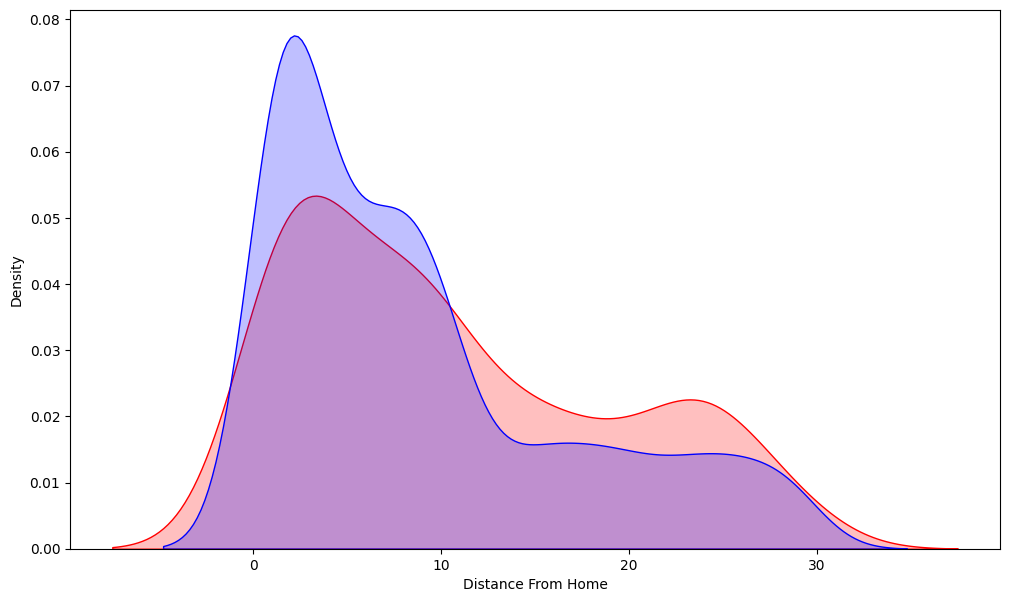

In [25]:

# KDE (Kernel Density Estimate) is used for visualizing the Probability Density of a continuous variable.
# KDE describes the probability density at different values in a continuous variable.

plt.figure(figsize=(12,7))

sns.kdeplot(left_df['DistanceFromHome'], label = 'Employees who left', shade = True, color = 'r')
sns.kdeplot(stayed_df['DistanceFromHome'], label = 'Employees who Stayed', shade = True, color = 'b')

plt.xlabel('Distance From Home')

/tmp/ipykernel_4934/1029930472.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['YearsWithCurrManager'], label = 'Employees who left', shade = True, color = 'r')
/tmp/ipykernel_4934/1029930472.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['YearsWithCurrManager'], label = 'Employees who Stayed', shade = True, color = 'b')


Text(0.5, 0, 'Years With Current Manager')

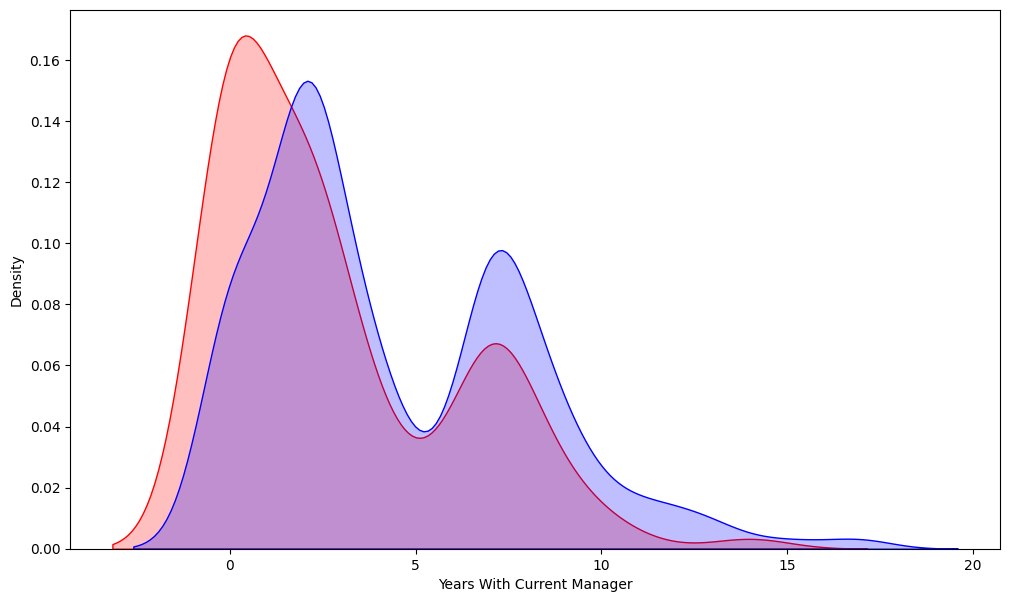

In [26]:
plt.figure(figsize=(12,7))

sns.kdeplot(left_df['YearsWithCurrManager'], label = 'Employees who left', shade = True, color = 'r')
sns.kdeplot(stayed_df['YearsWithCurrManager'], label = 'Employees who Stayed', shade = True, color = 'b')

plt.xlabel('Years With Current Manager')

/tmp/ipykernel_4934/3858665175.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['TotalWorkingYears'], shade = True, label = 'Employees who left', color = 'r')
/tmp/ipykernel_4934/3858665175.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['TotalWorkingYears'], shade = True, label = 'Employees who Stayed', color = 'b')


Text(0.5, 0, 'Total Working Years')

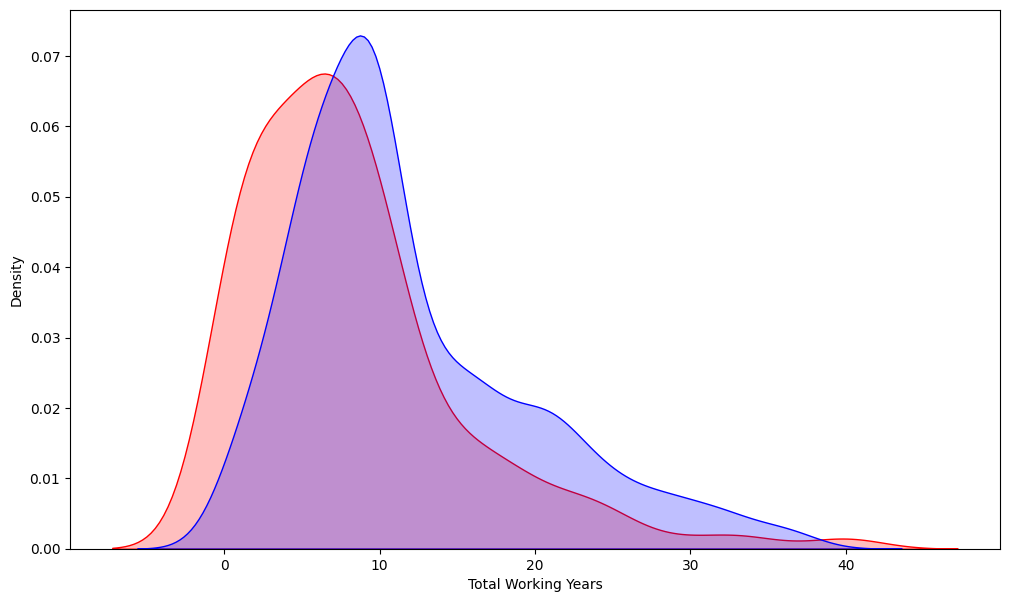

In [27]:
plt.figure(figsize=(12,7))

sns.kdeplot(left_df['TotalWorkingYears'], shade = True, label = 'Employees who left', color = 'r')
sns.kdeplot(stayed_df['TotalWorkingYears'], shade = True, label = 'Employees who Stayed', color = 'b')

plt.xlabel('Total Working Years')

<Axes: xlabel='MonthlyIncome', ylabel='Gender'>

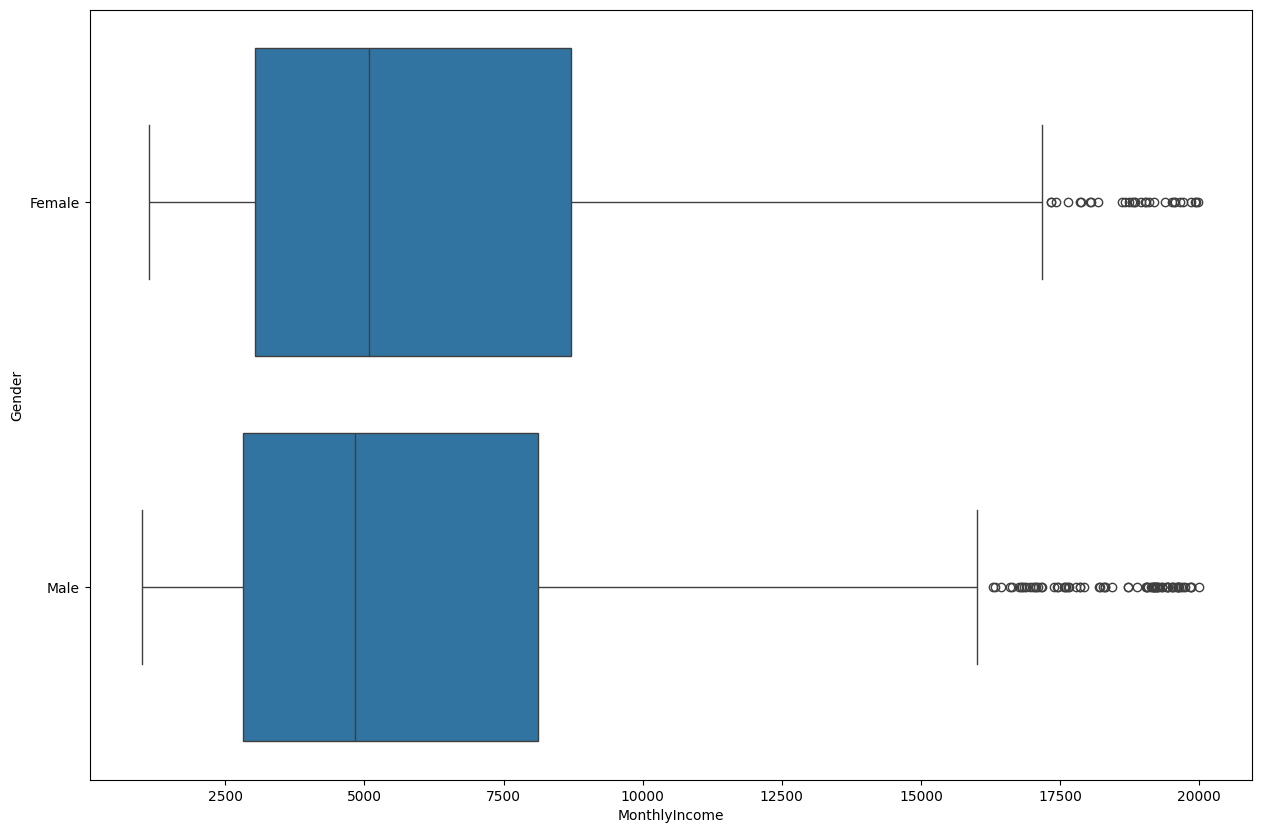

In [28]:
# Let's see the Gender vs. Monthly Income
plt.figure(figsize=(15, 10))
sns.boxplot(x = 'MonthlyIncome', y = 'Gender', data = employee_df)

<Axes: xlabel='MonthlyIncome', ylabel='JobRole'>

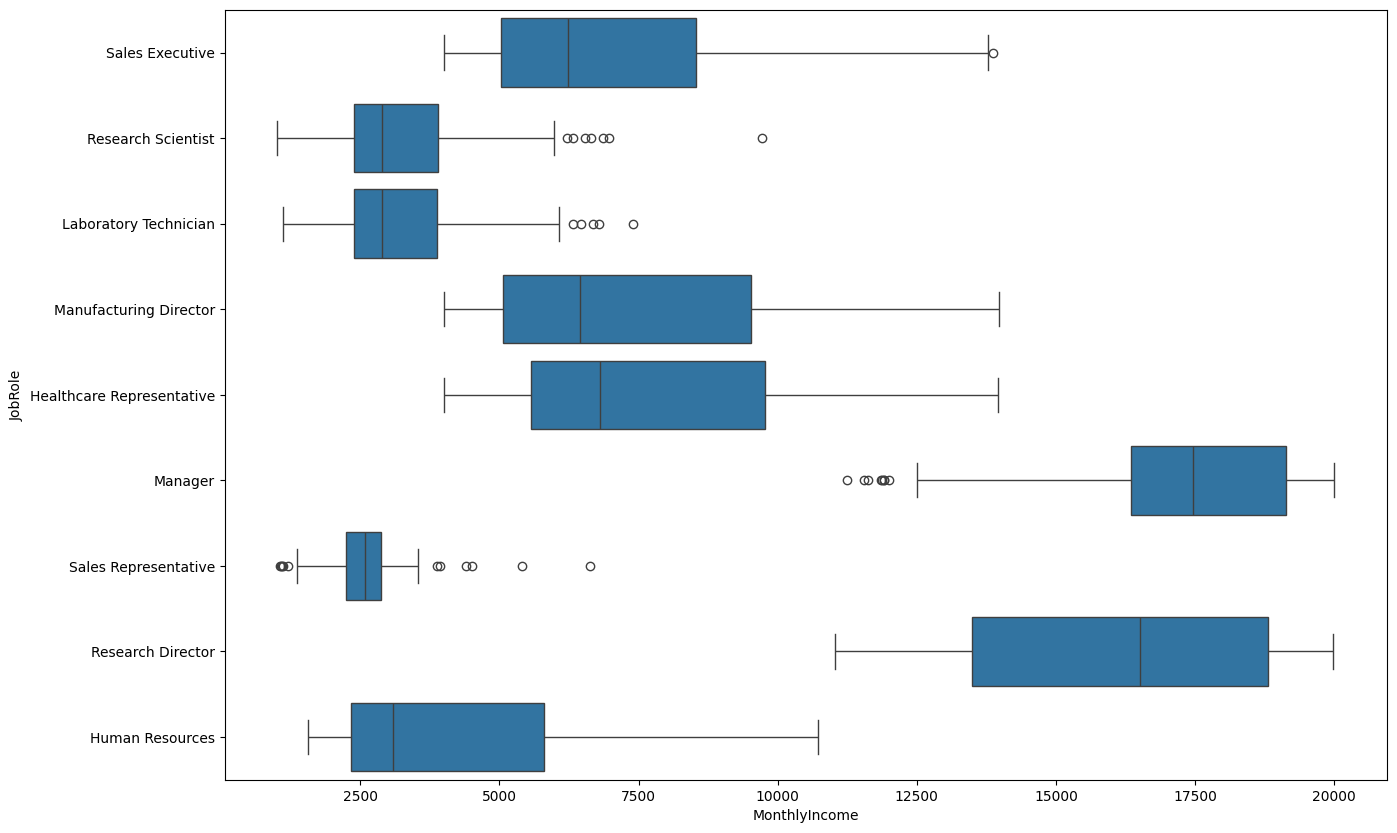

In [29]:
# Let's see the monthly income vs. job role
plt.figure(figsize=(15, 10))
sns.boxplot(x = 'MonthlyIncome', y = 'JobRole', data = employee_df)

# Create Testing and Training Dataset & Perform Data Cleaning

In [30]:
X_cat = employee_df[['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']]
X_cat

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus
0,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single
1,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married
2,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single
3,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married
4,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married
...,...,...,...,...,...,...
1465,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married
1466,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married
1467,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married
1468,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married


In [31]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder()
X_cat = onehotencoder.fit_transform(X_cat).toarray()

In [32]:
X_cat.shape

(1470, 26)

In [33]:
X_cat = pd.DataFrame(X_cat)

In [34]:
X_cat

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1466,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1467,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1468,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [35]:
numeric_df

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,2,94,3,2,4,5993,...,3,1,0,8,0,1,6,4,0,5
1,49,279,8,1,3,61,2,2,2,5130,...,4,4,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,92,2,1,3,2090,...,3,2,0,7,3,3,0,0,0,0
3,33,1392,3,4,4,56,3,1,3,2909,...,3,3,0,8,3,3,8,7,3,0
4,27,591,2,1,1,40,3,1,2,3468,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,3,3,1,17,3,3,5,2,0,3
1466,39,613,6,1,4,42,2,3,1,9991,...,3,1,1,9,5,3,7,7,1,7
1467,27,155,4,3,2,87,4,2,2,6142,...,4,2,1,6,0,3,6,2,0,3
1468,49,1023,2,3,4,63,2,2,2,5390,...,3,4,0,17,3,2,9,6,0,8


In [36]:
X_all = pd.concat([X_cat, numeric_df], axis = 1)
X_all

,0,1,2,3,4,5,6,7,8,9,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3,1,0,8,0,1,6,4,0,5
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,4,4,1,10,3,3,10,7,1,7
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3,2,0,7,3,3,0,0,0,0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,3,3,0,8,3,3,8,7,3,0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3,3,1,17,3,3,5,2,0,3
1466,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3,1,1,9,5,3,7,7,1,7
1467,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,4,2,1,6,0,3,6,2,0,3
1468,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,3,4,0,17,3,2,9,6,0,8


In [37]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   0                         1470 non-null   float64
 1   1                         1470 non-null   float64
 2   2                         1470 non-null   float64
 3   3                         1470 non-null   float64
 4   4                         1470 non-null   float64
 5   5                         1470 non-null   float64
 6   6                         1470 non-null   float64
 7   7                         1470 non-null   float64
 8   8                         1470 non-null   float64
 9   9                         1470 non-null   float64
 10  10                        1470 non-null   float64
 11  11                        1470 non-null   float64
 12  12                        1470 non-null   float64
 13  13                        1470 non-null   float64
 14  14      

In [38]:
X_all.columns = X_all.columns.astype(str)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X_all)

print("X_all column types converted and scaling applied. You can now use 'X'.")

X_all column types converted and scaling applied. You can now use 'X'.


In [39]:
X

array([[0.        , 0.        , 1.        , ..., 0.22222222, 0.        ,
        0.29411765],
       [0.        , 1.        , 0.        , ..., 0.38888889, 0.06666667,
        0.41176471],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 1.        , ..., 0.11111111, 0.        ,
        0.17647059],
       [0.        , 1.        , 0.        , ..., 0.33333333, 0.        ,
        0.47058824],
       [0.        , 0.        , 1.        , ..., 0.16666667, 0.06666667,
        0.11764706]])

In [40]:
y = employee_df['Attrition']



# Train and Evaluate a Logistic Regression Classifier

## Logistic Regression Classifier

In [41]:
from numpy.random import seed
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42) # Added random_state for reproducibility

from sklearn.linear_model import LogisticRegression
model_lg = LogisticRegression(random_state=42) # Specify solver to avoid warning
model_lg.fit(X_train, y_train)

y_pred = model_lg.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy: {:.2f}%".format(100 * accuracy_score(y_pred, y_test)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 89.67%

Confusion Matrix:
 [[311   9]
 [ 29  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       320
           1       0.68      0.40      0.50        48

    accuracy                           0.90       368
   macro avg       0.80      0.68      0.72       368
weighted avg       0.88      0.90      0.88       368



There is a problem with the accuracy paradox: It is observed that there is very high precision in classifying class 0 relative to class 1, reaching an accuracy of 89.67%, due to the dataset being highly unbalanced. The problem is that the model trained in this way is very poor at detecting class 0. Therefore, regularization is necessary; the first option is to add `class_weight='balanced'` as a hyperparameter.

## Logistic Regression Classifier class_weight='balanced' - SI

In [42]:
from numpy.random import seed
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42) # Added random_state for reproducibility

from sklearn.linear_model import LogisticRegression
model_lg2 = LogisticRegression(class_weight='balanced',random_state=42) # Specify solver to avoid warning
model_lg2.fit(X_train, y_train)

y_pred = model_lg2.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy: {:.2f}%".format(100 * accuracy_score(y_pred, y_test)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 76.09%

Confusion Matrix:
 [[250  70]
 [ 18  30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       320
           1       0.30      0.62      0.41        48

    accuracy                           0.76       368
   macro avg       0.62      0.70      0.63       368
weighted avg       0.85      0.76      0.79       368



By adding `class_weight='balanced'`, the model went from detecting 19 resignations to detecting 30 resignations out of a possible 48. That's 11 employees at risk who would have been lost before.

In [43]:
from imblearn.over_sampling import SMOTE


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42) # Added random_state for reproducibility

# Initialize SMOTE
oversampler = SMOTE(random_state=42)

# Apply SMOTE to the training data to balance the classes
X_train_smote, y_train_smote = oversampler.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Class distribution of y_train before SMOTE:\n{y_train.value_counts()}")
print(f"Class distribution of y_train after SMOTE:\n{y_train_smote.value_counts()}")


Shape of X_train before SMOTE: (1102, 50)
Shape of X_train after SMOTE: (1826, 50)
Class distribution of y_train before SMOTE:
Attrition
0    913
1    189
Name: count, dtype: int64
Class distribution of y_train after SMOTE:
Attrition
0    913
1    913
Name: count, dtype: int64


In [44]:
# Train the deep learning model with SMOTE balanced data

from sklearn.linear_model import LogisticRegression
model_lgsmote = LogisticRegression(class_weight='balanced',random_state=42) # Specify solver to avoid warning
model_lgsmote.fit(X_train_smote, y_train_smote)

y_pred = model_lgsmote.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy: {:.2f}%".format(100 * accuracy_score(y_pred, y_test)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 76.63%

Confusion Matrix:
 [[251  69]
 [ 17  31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.78      0.85       320
           1       0.31      0.65      0.42        48

    accuracy                           0.77       368
   macro avg       0.62      0.72      0.64       368
weighted avg       0.85      0.77      0.80       368



In [45]:
y_test.value_counts()

,count
Attrition,
0,320
1,48


In [46]:
y_train_smote.value_counts()

,count
Attrition,
0,913
1,913


## Logistic Regression Cross-Validation and SMOTE

To ensure a robust evaluation of the Logistic Regression model, I performed stratified cross-validation. This technique is particularly useful for imbalanced datasets like ours, as it maintains the proportion of each class (employees who stay vs. those who leave) in each fold, leading to more reliable performance estimates. The primary metric for evaluation here is Recall, as it's critical to correctly identify as many employees at risk of attrition as possible.

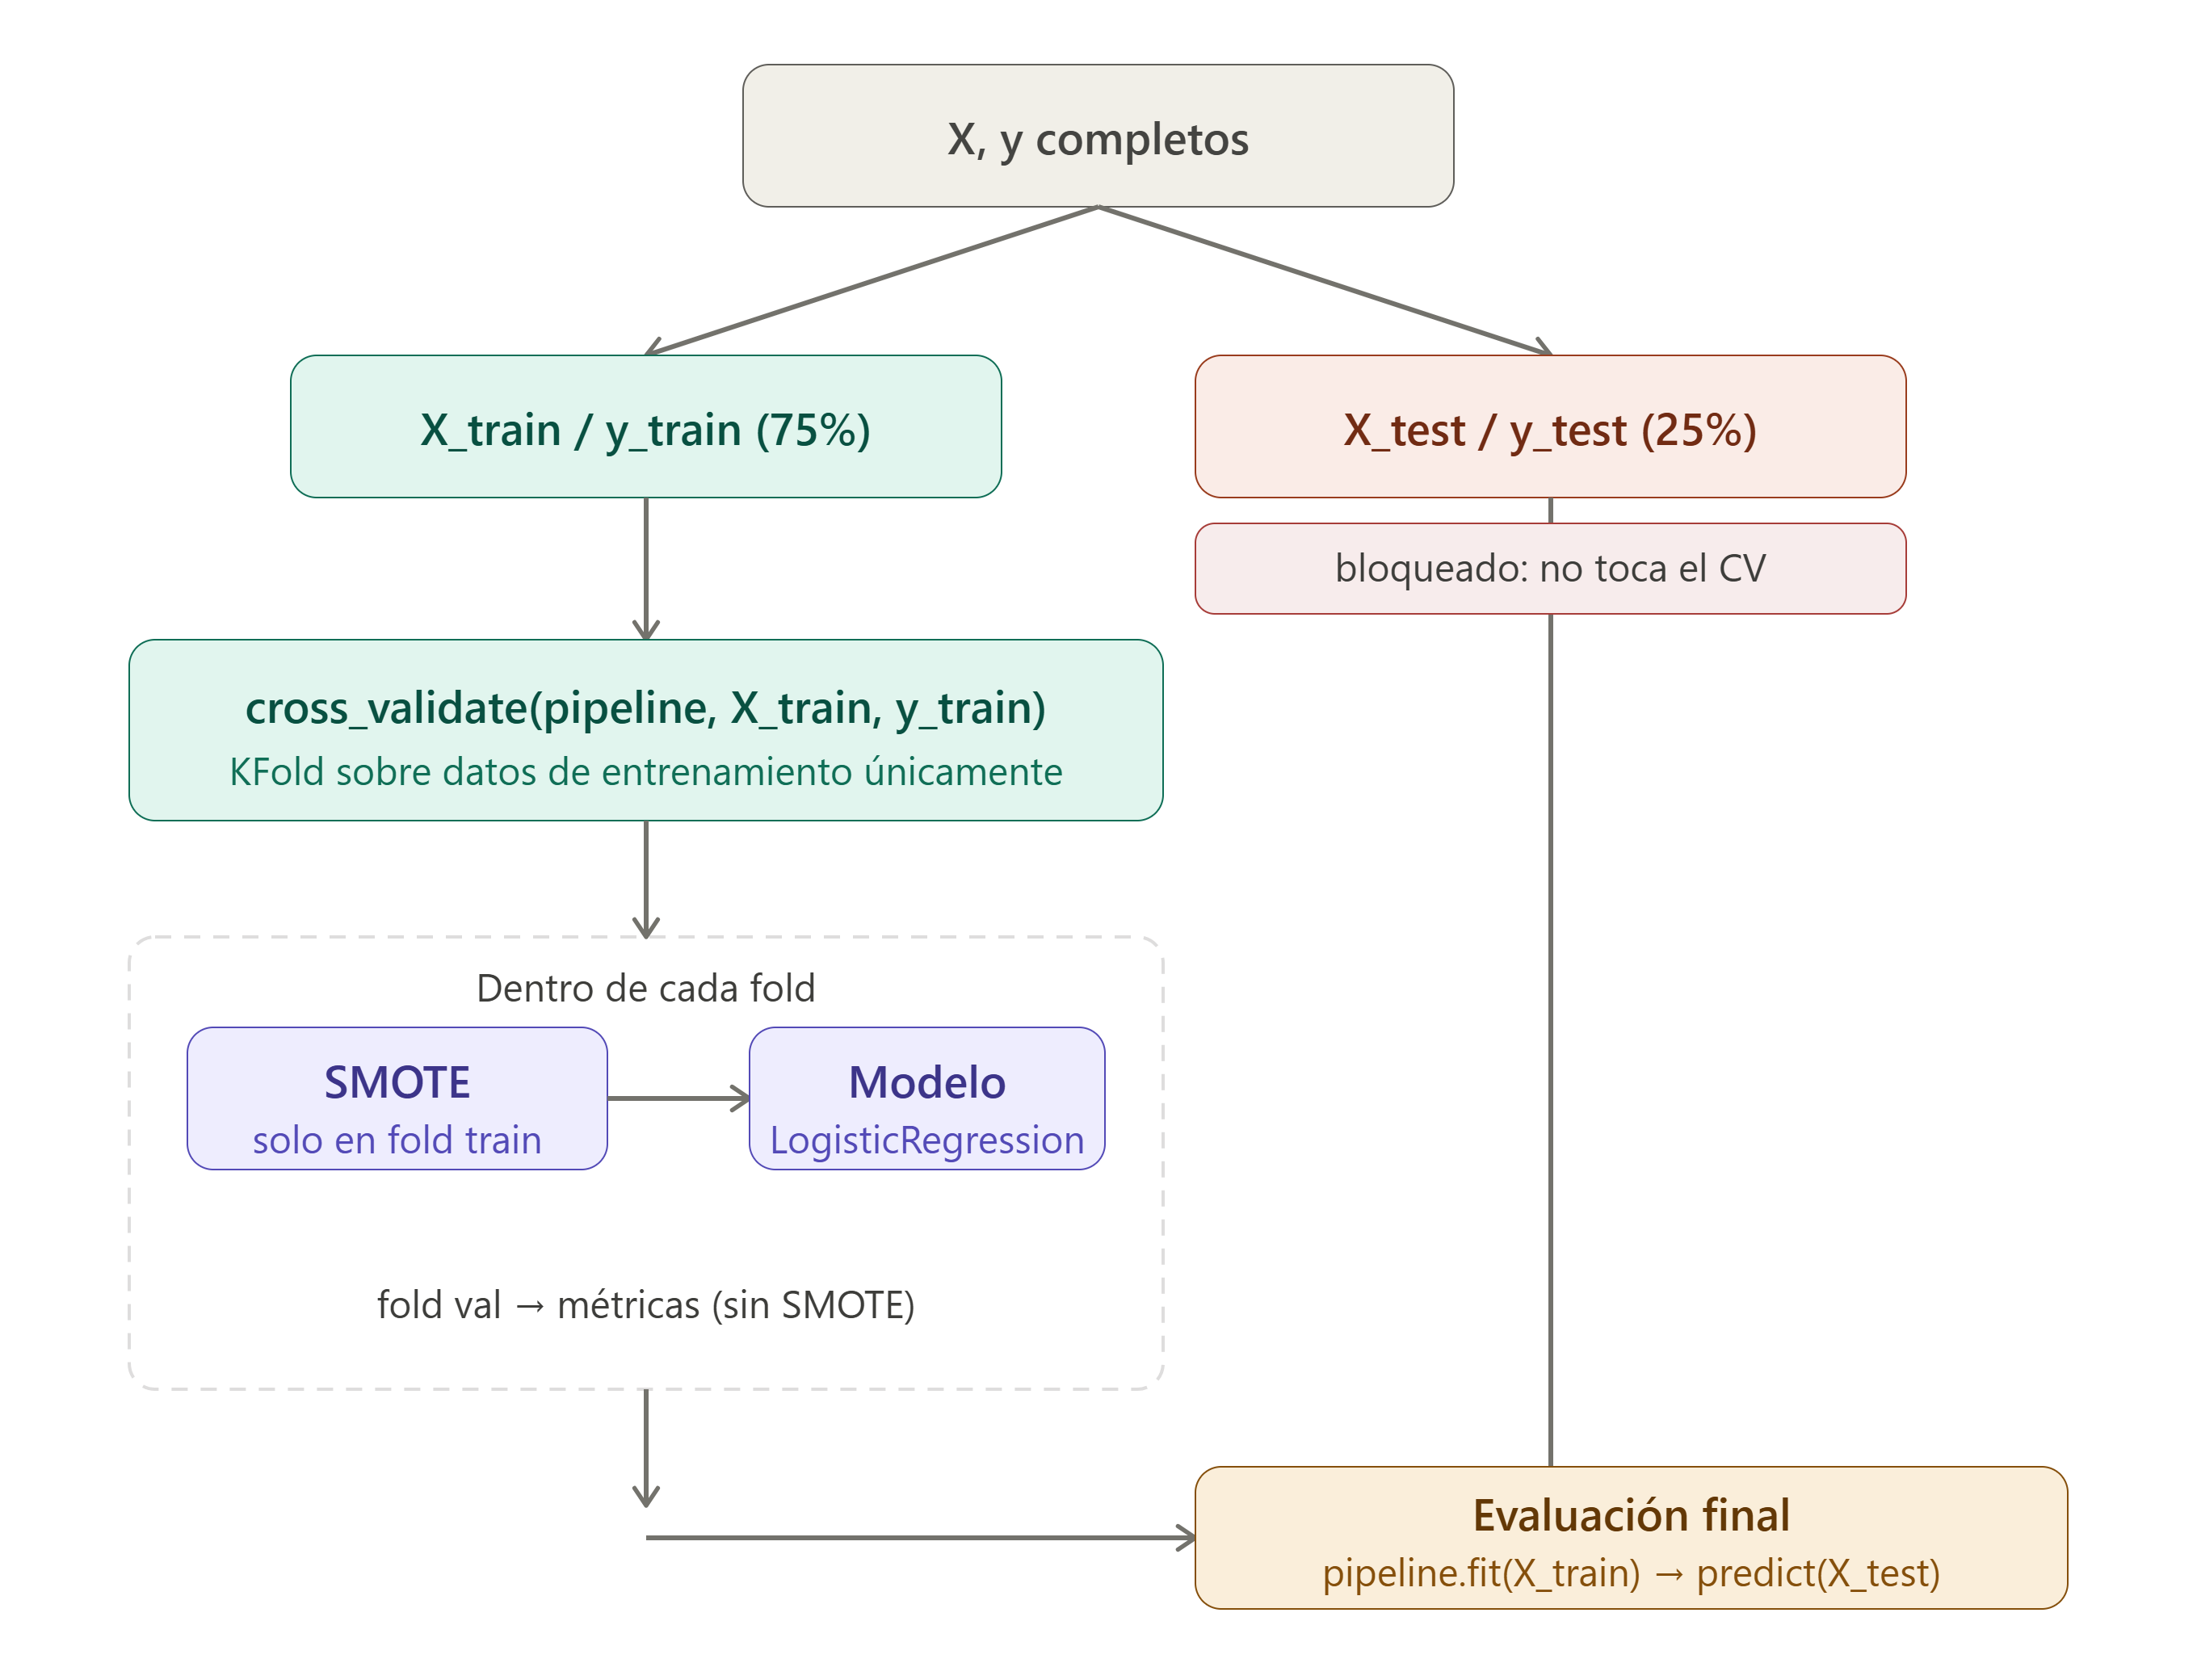

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.pipeline import Pipeline          # ← imblearn, no sklearn
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Split primero — X_test queda bloqueado hasta el final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y  # stratify es buena práctica con desbalance
)

# 2. Pipeline: SMOTE solo dentro de cada fold
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   LogisticRegression(max_iter=1000, random_state=42)),
    # sin class_weight='balanced' — SMOTE ya resuelve el desbalance
])

# 3. Cross-validation sobre X_train únicamente
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,   # ← X_train, no X completo
    cv=kf,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    return_train_score=True,
)

metrics = {
    "Accuracy":  ("test_accuracy",           "train_accuracy"),
    "Precision": ("test_precision_weighted", "train_precision_weighted"),
    "Recall":    ("test_recall_weighted",    "train_recall_weighted"),
    "F1 Score":  ("test_f1_weighted",        "train_f1_weighted"),
}

for name, (test_key, train_key) in metrics.items():
    test_scores  = cv_results[test_key]
    train_scores = cv_results[train_key]
    print(f"\n{name}:")
    print(f"  Folds       : {np.round(test_scores, 4)}")
    print(f"  Test  media : {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Train media : {train_scores.mean():.4f} (+/- {train_scores.std():.4f})")

gap = cv_results["train_accuracy"].mean() - cv_results["test_accuracy"].mean()
print(f"\nGap train-test (accuracy): {gap:.4f}", end=" ")
print("→ posible overfitting" if gap > 0.05 else "→ modelo bien generalizado")

# 4. Evaluación final — ahora sí se usa X_test
pipeline.fit(X_train, y_train)        # ← fit sobre todo el train
y_pred = pipeline.predict(X_test)

print(f"\nAccuracy final : {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n",       confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n",  classification_report(y_test, y_pred))


Accuracy:
  Folds       : [0.7692 0.7828 0.7773 0.8    0.8045]
  Test  media : 0.7868 (+/- 0.0135)
  Train media : 0.8040 (+/- 0.0095)

Precision:
  Folds       : [0.853  0.8525 0.8481 0.8467 0.857 ]
  Test  media : 0.8515 (+/- 0.0037)
  Train media : 0.8706 (+/- 0.0055)

Recall:
  Folds       : [0.7692 0.7828 0.7773 0.8    0.8045]
  Test  media : 0.7868 (+/- 0.0135)
  Train media : 0.8040 (+/- 0.0095)

F1 Score:
  Folds       : [0.7906 0.8057 0.7979 0.8181 0.8235]
  Test  media : 0.8072 (+/- 0.0123)
  Train media : 0.8239 (+/- 0.0076)

Gap train-test (accuracy): 0.0172 → modelo bien generalizado

Accuracy final : 0.7935

Confusion Matrix:
 [[256  53]
 [ 23  36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.83      0.87       309
           1       0.40      0.61      0.49        59

    accuracy                           0.79       368
   macro avg       0.66      0.72      0.68       368
weighted avg       0.84      0

#  Cross-Validation for Random Forest Classifier and Grid Search

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Pipeline
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   RandomForestClassifier(random_state=42, n_jobs=-1)),
])

# 3. Grid de hiperparámetros
#    Prefijo "clf__" porque el paso se llama "clf" en el pipeline
param_grid = {
    "clf__n_estimators":      [100, 200, 400],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__max_features":      ["sqrt", "log2"],
}

# 4. GridSearchCV — usa CV interno para seleccionar parámetros
#    Importante: también sobre X_train únicamente
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# 5. Resultados del grid search
print("=== Grid Search Results ===")
print(f"Mejor F1 (CV)  : {grid_search.best_score_:.4f}")
print(f"Mejores params : {grid_search.best_params_}")

# 6. KV Analize
best_pipeline = grid_search.best_estimator_

cv_results = cross_validate(
    best_pipeline, X_train, y_train,
    cv=kf,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    return_train_score=True,
)

metrics = {
    "Accuracy":  ("test_accuracy",           "train_accuracy"),
    "Precision": ("test_precision_weighted", "train_precision_weighted"),
    "Recall":    ("test_recall_weighted",    "train_recall_weighted"),
    "F1 Score":  ("test_f1_weighted",        "train_f1_weighted"),
}

print("\n=== CV with better paramiters ===")
for name, (test_key, train_key) in metrics.items():
    test_scores  = cv_results[test_key]
    train_scores = cv_results[train_key]
    print(f"\n{name}:")
    print(f"  Folds       : {np.round(test_scores, 4)}")
    print(f"  Test  median : {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Train meen : {train_scores.mean():.4f} (+/- {train_scores.std():.4f})")

gap = cv_results["train_accuracy"].mean() - cv_results["test_accuracy"].mean()
print(f"\nGap train-test (accuracy): {gap:.4f}", end=" ")
print("→ posible overfitting" if gap > 0.05 else "→ model good generalize")

# 7.Final Evaluation ob X_test — once time
y_pred = grid_search.predict(X_test)

print(f"\n=== Final Evaluations (X_test) ===")
print(f"Accuracy final : {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n",      confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
=== Grid Search Results ===
Mejor F1 (CV)  : 0.8558
Mejores params : {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 100}

=== CV with better paramiters ===

Accuracy:
  Folds       : [0.8507 0.8733 0.8909 0.8773 0.8773]
  Test  median : 0.8739 (+/- 0.0131)
  Train meen : 0.9925 (+/- 0.0014)

Precision:
  Folds       : [0.8392 0.857  0.8918 0.857  0.8587]
  Test  median : 0.8607 (+/- 0.0171)
  Train meen : 0.9925 (+/- 0.0014)

Recall:
  Folds       : [0.8507 0.8733 0.8909 0.8773 0.8773]
  Test  median : 0.8739 (+/- 0.0131)
  Train meen : 0.9925 (+/- 0.0014)

F1 Score:
  Folds       : [0.828  0.8564 0.8756 0.8591 0.86  ]
  Test  median : 0.8558 (+/- 0.0155)
  Train meen : 0.9925 (+/- 0.0014)

Gap train-test (accuracy): 0.1186 → posible overfitting

=== Final Evaluations (X_test) ===
Accuracy final : 0.8505

Confusion Matrix:
 [[296  13]
 [ 42  17]]

Classification Report:
 

#  Cross-Validation for CatBoostClassifier and Grid Search

In [49]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [50]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Pipeline
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   CatBoostClassifier(
                  random_seed=42,
                  verbose=0,
                  auto_class_weights=None,  # SMOTE
              )),
])

# 3. Grid de hiperparamiter
param_grid = {
    "clf__iterations":        [200, 400, 600],
    "clf__learning_rate":     [0.01, 0.05, 0.1],
    "clf__depth":             [4, 6, 8],
    "clf__l2_leaf_reg":       [1, 3, 5],      # regularizarion L2
}

# 4. GridSearchCV on X_train
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# 5. Results grid search
print("=== Grid Search Results ===")
print(f"Mejor F1 (CV)  : {grid_search.best_score_:.4f}")
print(f"Mejores params : {grid_search.best_params_}")

# 6. KV Analize better estimator
best_pipeline = grid_search.best_estimator_

cv_results = cross_validate(
    best_pipeline, X_train, y_train,
    cv=kf,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    return_train_score=True,
)

metrics = {
    "Accuracy":  ("test_accuracy",           "train_accuracy"),
    "Precision": ("test_precision_weighted", "train_precision_weighted"),
    "Recall":    ("test_recall_weighted",    "train_recall_weighted"),
    "F1 Score":  ("test_f1_weighted",        "train_f1_weighted"),
}

print("\n=== CV with better paramiters ===")
for name, (test_key, train_key) in metrics.items():
    test_scores  = cv_results[test_key]
    train_scores = cv_results[train_key]
    print(f"\n{name}:")
    print(f"  Folds       : {np.round(test_scores, 4)}")
    print(f"  Test  median : {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Train mean : {train_scores.mean():.4f} (+/- {train_scores.std():.4f})")

gap = cv_results["train_accuracy"].mean() - cv_results["test_accuracy"].mean()
print(f"\nGap train-test (accuracy): {gap:.4f}", end=" ")
print("→ Overfitting" if gap > 0.05 else "→ model good generalize")

# 7. Final Evaluation
y_pred = grid_search.predict(X_test)

print(f"\n=== Final Evaluation (X_test) ===")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n",      confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
=== Grid Search Results ===
Mejor F1 (CV)  : 0.8720
Mejores params : {'clf__depth': 6, 'clf__iterations': 400, 'clf__l2_leaf_reg': 1, 'clf__learning_rate': 0.1}

=== CV with better paramiters ===

Accuracy:
  Folds       : [0.8733 0.8733 0.8955 0.8955 0.8955]
  Test  median : 0.8866 (+/- 0.0109)
  Train mean : 1.0000 (+/- 0.0000)

Precision:
  Folds       : [0.8715 0.857  0.8912 0.8836 0.8847]
  Test  median : 0.8776 (+/- 0.0121)
  Train mean : 1.0000 (+/- 0.0000)

Recall:
  Folds       : [0.8733 0.8733 0.8955 0.8955 0.8955]
  Test  median : 0.8866 (+/- 0.0109)
  Train mean : 1.0000 (+/- 0.0000)

F1 Score:
  Folds       : [0.8552 0.8534 0.8855 0.88   0.8857]
  Test  median : 0.8720 (+/- 0.0146)
  Train mean : 1.0000 (+/- 0.0000)

Gap train-test (accuracy): 0.1134 → Overfitting

=== Final Evaluation (X_test) ===
Final Accuracy: 0.8614

Confusion Matrix:
 [[302   7]
 [ 44  15]]

Classification Report:
               precision 

# Train and Evaluate a Deep Learning Model

In [51]:
import tensorflow as tf

In [53]:
model_tf = tf.keras.models.Sequential()
model_tf.add(tf.keras.layers.Dense(units=500, activation='relu', input_shape=(50, )))
model_tf.add(tf.keras.layers.Dense(units=500, activation='relu'))
model_tf.add(tf.keras.layers.Dense(units=500, activation='relu'))
model_tf.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │        25,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,001 (2.01 MB)

 Trainable params: 527,001 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model_tf.compile(optimizer='Adam', loss='binary_crossentropy', metrics = ['accuracy'])

In [56]:
# oversampler = SMOTE(random_state=42)
# smote_train, smote_target = oversampler.fit_sample(X_train, y_train)
# epochs_hist = model_tf.fit(smote_train, smote_target, epochs = 100, batch_size = 50)
epochs_hist = model_tf.fit(X_train, y_train, epochs = 100, batch_size = 50)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8385 - loss: 0.4275
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8593 - loss: 0.3422
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8820 - loss: 0.3022
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8993 - loss: 0.2848
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9183 - loss: 0.2288
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9292 - loss: 0.2014
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9483 - loss: 0.1603
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9428 - loss: 0.1481
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9428 - loss: 0.1298
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9619 - loss: 0.0983
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9782 - loss: 0.0628
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - ac

In [57]:
y_pred = model_tf.predict(X_test)
y_pred = (y_pred > 0.5)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


In [58]:
epochs_hist.history.keys()

dict_keys(['accuracy', 'loss'])

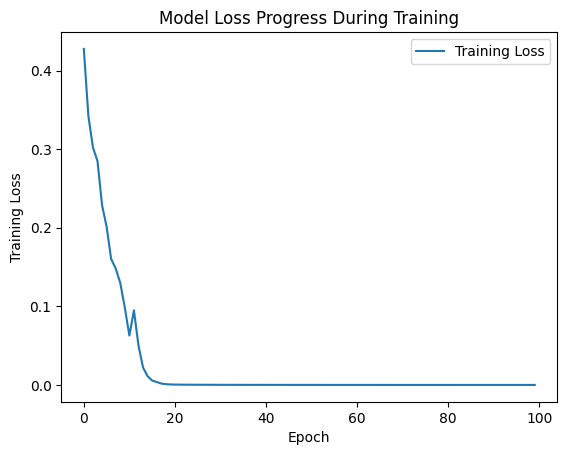

In [59]:
plt.plot(epochs_hist.history['loss'])
plt.title('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training Loss'])

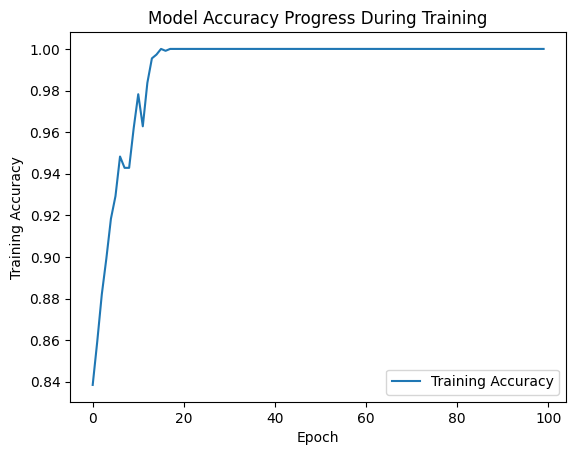

In [60]:
plt.plot(epochs_hist.history['accuracy'])
plt.title('Model Accuracy Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend(['Training Accuracy'])

<Axes: >

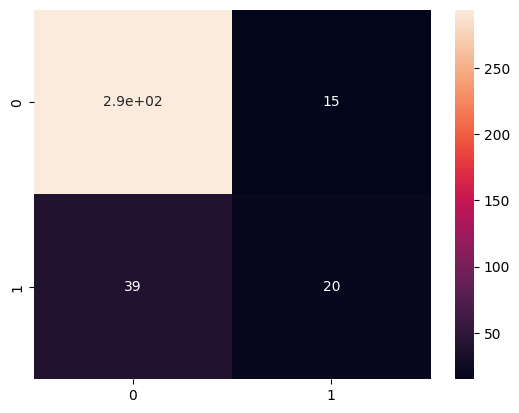

In [61]:
# Testing Set Performance
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92       309
           1       0.57      0.34      0.43        59

    accuracy                           0.85       368
   macro avg       0.73      0.65      0.67       368
weighted avg       0.83      0.85      0.84       368



## Comparison of Average Recall Scores


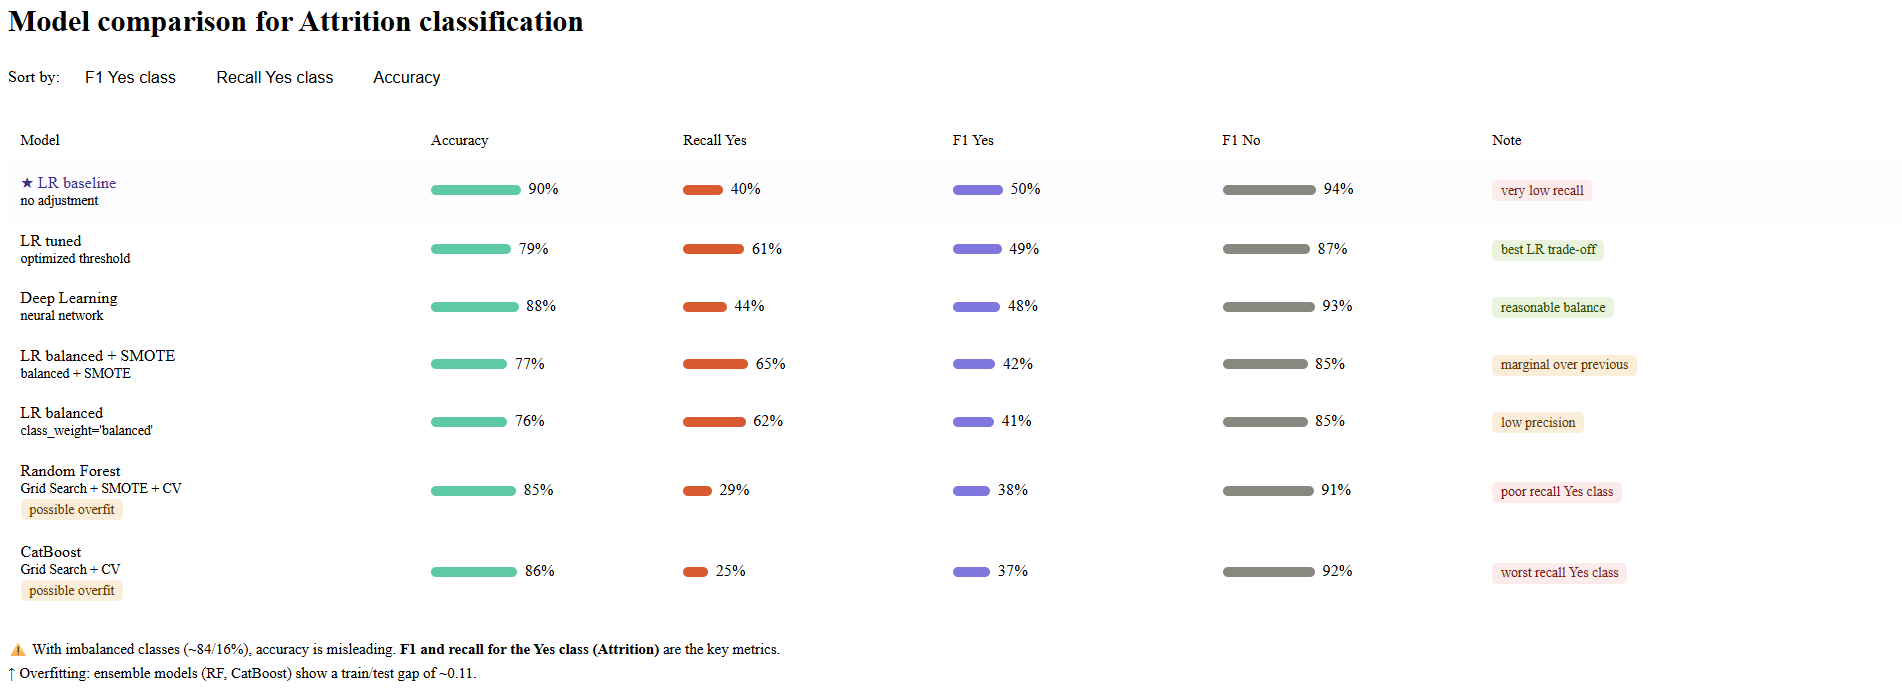

## Conclusion:

The verdict depends on your objective:

If you want to detect the maximum number of employees who will leave (prioritize recall): the best option is LR balanced or LR balanced + SMOTE, with a recall of 62–65% in the Yes class. The cost is more false positives (accuracy ~30%).

If you want the best balance between detection and avoiding false alarms (prioritize F1): the winner is LR base (F1=0.50) or Deep Learning (F1=0.48).

Surprisingly, the simplest models win here.

Random Forest and CatBoost, despite their high accuracy and extensive tuning, are the worst at detecting Attrition=Yes — recall of 25–29%.

Grid Search optimized the average F1 of the SMOTE-balanced training set, but in the real test, it still ignores the minority class. The gap between training and testing (~0.11) also suggests overfitting.

Specific recommendation: start with the adjusted LR with optimized threshold (the fourth variant) as a solid baseline—it has the best trade-off between recall (61%) and accuracy (40%) in the Yes class, without overfitting. If you need even more recall at the expense of accuracy, use balanced LR + SMOTE.